<h1 style="color:#ffffff; background-color:#5C2A3D; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Week 5 — Day 1: Unsupervised Learning &amp; K-Means</h1>
<p style="color:#F2C14E; background-color:#7A3B52; text-align:center; font-weight:bold; font-style:italic; padding:6px 10px; border-radius:6px; margin-top:0; font-size:15px;">Finding Structure in Data With No Labels</p>


<a id="toc"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup</a></li>
<li><a href="#section1">1. Supervised vs. Unsupervised Learning</a></li>
<li><a href="#section2">2. What Clustering Does</a></li>
<li><a href="#section3">3. K-Means, Step by Step</a></li>
<li><a href="#section4">4. Choosing k: the Elbow Method</a></li>
<li><a href="#section5">5. Choosing k: the Silhouette Score</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference</a></li>
<li><a href="#section8">8. Hands-On Lab — K-Means Clustering</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup</h2>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> This week moves from <b>supervised learning</b> (Weeks 3–4) into <b>unsupervised learning</b>, so the core toolkit shifts from <code>train_test_split</code> and classifiers toward clustering and scaling tools.
</div>


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sklearn
print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

scikit-learn version: 1.7.2
pandas version: 2.3.3
numpy version: 2.3.5


<a id="section1"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Supervised vs. Unsupervised Learning</h2>
In supervised learning (Weeks 3–4), every training example had a known correct answer (the target <code>y</code>). <b>Unsupervised learning</b> works on data with <b>no labels at all</b> — there is no <code>y</code>. Instead of predicting a known answer, the goal is to discover hidden structure the data contains on its own: natural groupings, underlying dimensions, or unusual points.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#7A3B52; color:#F2C14E;"><th style="padding:8px; text-align:left;"></th><th style="padding:8px; text-align:left;">Supervised</th><th style="padding:8px; text-align:left;">Unsupervised</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Data</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Has labels (X and y)</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">No labels (X only)</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Goal</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Predict the known target</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Discover hidden structure</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Examples</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Regression, classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Clustering, dimensionality reduction, anomaly detection</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Evaluation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Compare prediction to true label</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">No ground truth — uses internal metrics and judgment</td></tr>
</table>
</div>


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Because there is no ground truth in unsupervised learning, evaluation depends on <b>internal metrics</b> (like the silhouette score, used later in this notebook) and human judgment, rather than comparing predictions against a known correct answer.
</div>


<a id="section2"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. What Clustering Does</h2>
<b>Clustering</b> groups data points so that points in the same group are similar to each other and different from points in other groups. It answers questions like <i>"what natural customer segments exist?"</i> without anyone having pre-defined those segments. Because there are no labels, the algorithm finds structure purely from the shape of the data.

The dataset used in this notebook, <code>customer_segmentation.csv</code>, contains three numeric features per customer — <code>Age</code>, <code>Annual_Income_k</code> (annual income in thousands), and <code>Spending_Score</code> (a 1-100 score based on spending behavior) — with no target column, since clustering does not need one.

In [2]:
df = pd.read_csv("customer_segmentation.csv")
print(df.shape)
df.head()

(200, 4)


,CustomerID,Age,Annual_Income_k,Spending_Score
0,96,36,48,49
1,16,23,30,66
2,31,23,27,63
3,159,29,73,100
4,129,30,91,78


In [3]:
df.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.620000,59.280000,49.640000
std,57.879185,12.059134,31.042548,28.006467
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.000000,28.750000,23.000000
50%,100.500000,38.000000,58.000000,50.000000
75%,150.250000,48.000000,90.000000,77.000000
max,200.000000,68.000000,122.000000,100.000000


<a id="section3"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. K-Means, Step by Step</h2>
<b>K-Means</b> is the most widely used clustering algorithm. It partitions data into a chosen number of clusters (<code>k</code>) by repeating two steps until stable:

<ul>
<li><b>Step 1</b> — Place <code>k</code> cluster centers ("centroids"), initially at random.</li>
<li><b>Step 2</b> — Assign each point to its nearest centroid.</li>
<li><b>Step 3</b> — Move each centroid to the mean position of the points assigned to it.</li>
<li><b>Repeat</b> steps 2–3 until the centroids stop moving.</li>
</ul>

<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <b>Always scale features before clustering.</b> K-Means uses distance, so an unscaled large-range feature (like income) would dominate a small-range one (like age) — the same <code>StandardScaler</code> discipline from Week 4.
</div>


In [4]:
features = ["Age", "Annual_Income_k", "Spending_Score"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(3))

Mean after scaling (should be ~0): [ 0. -0. -0.]
Std after scaling (should be ~1): [1. 1. 1.]


In [5]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

print("Cluster sizes:", np.bincount(labels))
print("\nFinal centroid positions (scaled space):")
print(km.cluster_centers_)

Cluster sizes: [ 50 105  45]

Final centroid positions (scaled space):
[[ 0.53870046  0.96754886 -0.83403841]
 [-0.78231911 -0.06009888  0.82868611]
 [ 1.22685519 -0.93482357 -1.00689157]]


<a id="section4"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Choosing k: the Elbow Method</h2>
K-Means needs you to choose <code>k</code> in advance, but the right <code>k</code> is rarely obvious. The <b>elbow method</b> runs K-Means for a range of <code>k</code> values and plots the <b>inertia</b> (total within-cluster distance) against <code>k</code>. Inertia always falls as <code>k</code> rises, but the rate of improvement drops sharply at the right <code>k</code> — creating an "elbow" in the plot. That elbow is the recommended <code>k</code>.

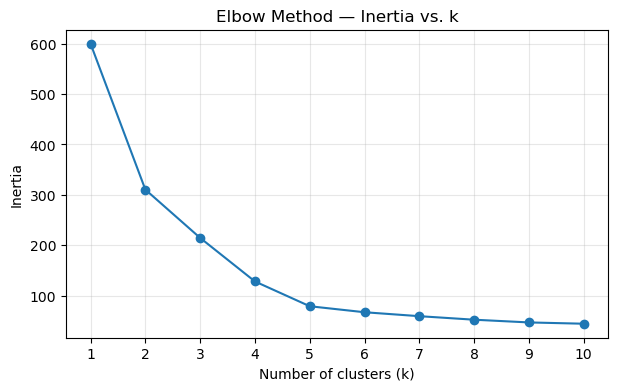

In [6]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km_k.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Inertia vs. k")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <b>Reading the plot:</b> inertia drops sharply from <code>k=1</code> to <code>k=4</code> or <code>k=5</code>, then flattens out. That bend is the elbow, and it lines up with the fact that this dataset was built from five underlying customer groups — the elbow method recovers that structure directly from the data, with no labels involved.
</div>


<a id="section5"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Choosing k: the Silhouette Score</h2>
The <b>silhouette score</b> is a more quantitative check: it measures how well each point sits inside its own cluster versus the nearest other cluster, on a scale from <b>-1 to +1</b>. A higher average silhouette score means better-defined clusters. Comparing the score across candidate <code>k</code> values gives a data-driven choice to confirm the elbow.

In [7]:
silhouette_scores = {}

for k in range(2, 11):  # silhouette score is undefined for k=1
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    score = silhouette_score(X_scaled, km_k.labels_)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k by silhouette score: {best_k}")

k=2: silhouette score = 0.4219
k=3: silhouette score = 0.4406
k=4: silhouette score = 0.5044
k=5: silhouette score = 0.5542
k=6: silhouette score = 0.5198
k=7: silhouette score = 0.4887
k=8: silhouette score = 0.4650
k=9: silhouette score = 0.4227
k=10: silhouette score = 0.4056

Best k by silhouette score: 5


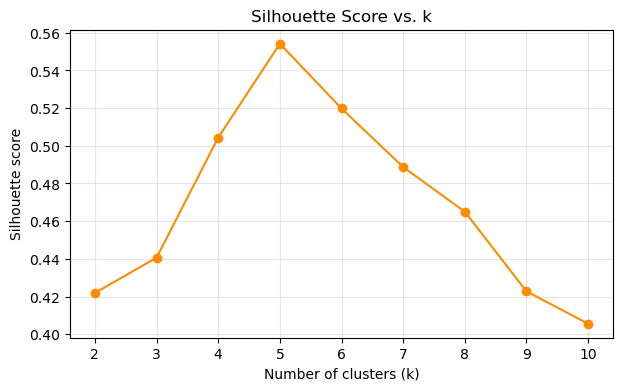

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs. k")
plt.grid(alpha=0.3)
plt.show()

<a id="section6"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Common Mistakes to Avoid</h2>
<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#7A3B52; color:#F2C14E;"><th style="padding:8px; text-align:left;">Mistake</th><th style="padding:8px; text-align:left;">Why It Hurts</th><th style="padding:8px; text-align:left;">Fix</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Skipping <code>StandardScaler</code> before clustering</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Large-range features (like income) dominate the distance calculation, distorting clusters</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Always scale numeric features before fitting K-Means</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Picking <code>k</code> by eye without checking metrics</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">The "obvious" elbow can be subjective, especially on real-world noisy data</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Confirm the elbow with the silhouette score</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Forgetting <code>random_state</code></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Centroid initialization is random, so cluster labels and boundaries change between runs</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fix <code>random_state=42</code> for reproducible results</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Using only 1–2 candidate <code>k</code> values</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Misses a better clustering that a wider search would find</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sweep a full range (e.g. 1–10) before deciding</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Treating cluster numbers as meaningful order</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Cluster <code>0</code> is not "less than" cluster <code>2</code> — labels are arbitrary IDs</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Interpret clusters by their feature averages, not their label number</td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Quick Reference</h2>
<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#7A3B52; color:#F2C14E;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Scale features</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>StandardScaler().fit_transform(X)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fit K-Means</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Get inertia</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>km.inertia_</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Get centroids</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>km.cluster_centers_</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Compute silhouette score</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>silhouette_score(X_scaled, labels)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Elbow sweep</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">loop <code>k</code> over a range, collect <code>km.inertia_</code> for each, plot</td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Hands-On Lab — K-Means Clustering</h2>
<div style="border-left:5px solid #9B6FD4; background-color:#f3edfb; padding:10px 15px; margin:10px 0; border-radius:4px; color:#4d3475;">
<b>Goal:</b> Using the <b>customer segmentation dataset</b> (<code>customer_segmentation.csv</code>), build a complete K-Means workflow end to end: load and scale &rarr; sweep <code>k</code> and find the elbow &rarr; confirm with the silhouette score &rarr; fit the final model and visualize &rarr; interpret each cluster.
</div>


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Load and scale the dataset</h3>


In [9]:
lab_df = pd.read_csv("customer_segmentation.csv")
lab_features = ["Age", "Annual_Income_k", "Spending_Score"]

X_lab = lab_df[lab_features]
X_lab_scaled = StandardScaler().fit_transform(X_lab)

print(lab_df.shape)
lab_df.head()

(200, 4)


,CustomerID,Age,Annual_Income_k,Spending_Score
0,96,36,48,49
1,16,23,30,66
2,31,23,27,63
3,159,29,73,100
4,129,30,91,78


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Run K-Means for k = 1 to 10 and plot the elbow</h3>


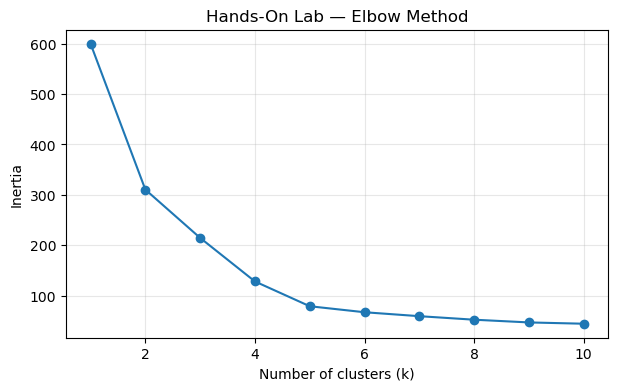

In [10]:
lab_inertias = []
for k in range(1, 11):
    km_lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_lab_scaled)
    lab_inertias.append(km_lab.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), lab_inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Hands-On Lab — Elbow Method")
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Compute the silhouette score for the top candidate k values</h3>


In [11]:
candidates = [4, 5, 6]
lab_silhouette = {}

for k in candidates:
    km_lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_lab_scaled)
    lab_silhouette[k] = silhouette_score(X_lab_scaled, km_lab.labels_)

for k, s in lab_silhouette.items():
    print(f"k={k}: silhouette score = {s:.4f}")

chosen_k = max(lab_silhouette, key=lab_silhouette.get)
print(f"\nChosen k: {chosen_k}")

k=4: silhouette score = 0.5044
k=5: silhouette score = 0.5542
k=6: silhouette score = 0.5198

Chosen k: 5


<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Fit the final model and visualize the clusters</h3>


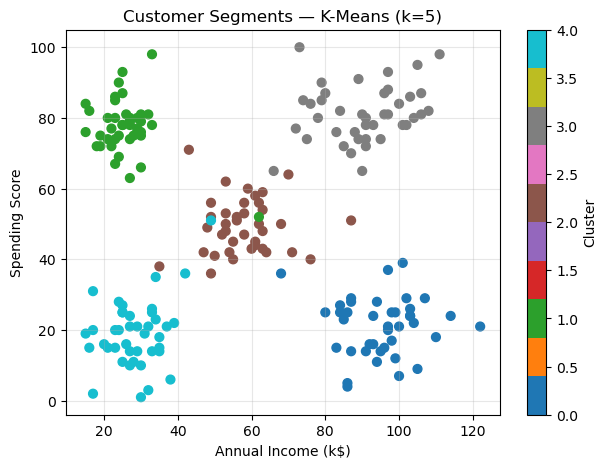

In [12]:
final_km = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
final_labels = final_km.fit_predict(X_lab_scaled)
lab_df["Cluster"] = final_labels

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    lab_df["Annual_Income_k"], lab_df["Spending_Score"],
    c=lab_df["Cluster"], cmap="tab10", s=40
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title(f"Customer Segments — K-Means (k={chosen_k})")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

<h3 style="color:#F2C14E; font-weight:bold; background-color:#2D3748; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Interpret the clusters</h3>


In [13]:
cluster_summary = lab_df.groupby("Cluster")[lab_features].mean().round(1)
cluster_summary["Count"] = lab_df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual_Income_k,Spending_Score,Count
Cluster,,,,
0,45.2,95.2,21.1,40
1,24.0,25.9,77.4,41
2,39.1,57.8,49.5,38
3,30.9,90.4,81.2,40
4,54.0,28.5,19.0,41


<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> Based on the <code>cluster_summary</code> table above, the five clusters map to five natural customer segments — for example, younger customers with lower income but high spending scores, older customers with high income but low spending scores, and a middle group with moderate values across all three features. These groupings were discovered purely from the shape of the data, with no target column and no predefined labels — this is the core difference from every supervised model built in Weeks 3–4.
</div>


<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Cluster Interpretation</b>

 - **Cluster 0 — High-income, low-spending customers:** These customers have relatively high income but low spending scores. A business could target them with personalized offers or loyalty incentives to encourage more spending.

- **Cluster 1 — Young, high-spending customers:** These customers are younger, have lower income, but spend heavily. They may respond well to promotions, trendy products, and affordable offers.

- **Cluster 2 — Average customers:** This group has moderate age, income, and spending levels. They represent balanced customers and could be targeted with general promotions and loyalty programs.

- **Cluster 3 — High-income, high-spending customers:** These are valuable customers with high income and high spending scores. A business could focus on premium products, VIP services, and retention strategies for this group.

- **Cluster 4 — Older, low-income, low-spending customers:** These customers are older and have relatively low income and spending scores. They may respond better to discounts, value-focused products, and budget-friendly offers.
</div>


<a id="section9"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #F0964B; background-color:#fef2e7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a4a13;">
<b>Important:</b> <ul>
<li>Always scale features with <code>StandardScaler</code> before running K-Means or computing distances.</li>
<li>Fix <code>random_state=42</code> (and <code>n_init=10</code>) so that clustering results are reproducible.</li>
<li>Never pick <code>k</code> from the elbow plot alone — confirm the choice with the silhouette score.</li>
<li>Interpret clusters by their <b>feature averages</b>, not by the arbitrary cluster label number.</li>
<li>Keep the elbow and silhouette sweeps in the notebook as evidence for the <code>k</code> that was chosen.</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#F2C14E; background-color:#7A3B52; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #E85D9A; background-color:#fdeef4; padding:10px 15px; margin:10px 0; border-radius:4px; color:#8a2b52;">
<b>Tip:</b> <ul>
<li><b>Unsupervised learning</b> finds structure in data that has no labels, evaluated with internal metrics instead of comparing to a known correct answer.</li>
<li><b>K-Means</b> partitions data into <code>k</code> clusters by repeatedly assigning points to the nearest centroid and recomputing centroids until they stabilize.</li>
<li>The <b>elbow method</b> suggests a <code>k</code> by looking for where inertia stops dropping sharply.</li>
<li>The <b>silhouette score</b> gives a quantitative, data-driven way to confirm or adjust the elbow's choice.</li>
<li><b>Scaling features</b> before clustering is essential, since K-Means relies entirely on distance.</li>
</ul>
</div>
<div style="border-left:5px solid #4A9DE0; background-color:#eaf4fc; padding:10px 15px; margin:10px 0; border-radius:4px; color:#1c4e6e;">
<b>Note:</b> <b>Where this leads next:</b> Day 2 introduces DBSCAN and hierarchical clustering — two alternatives to K-Means that do not require choosing <code>k</code> in advance and that handle irregularly shaped clusters and noise more gracefully.
</div>
